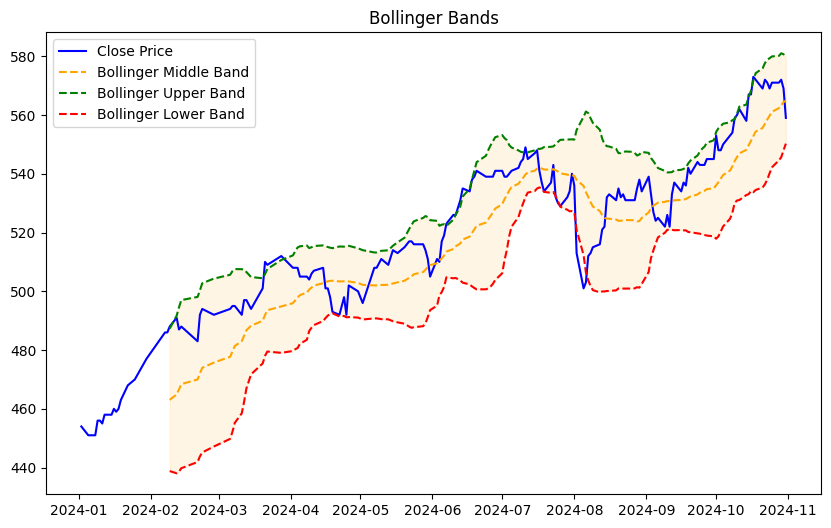

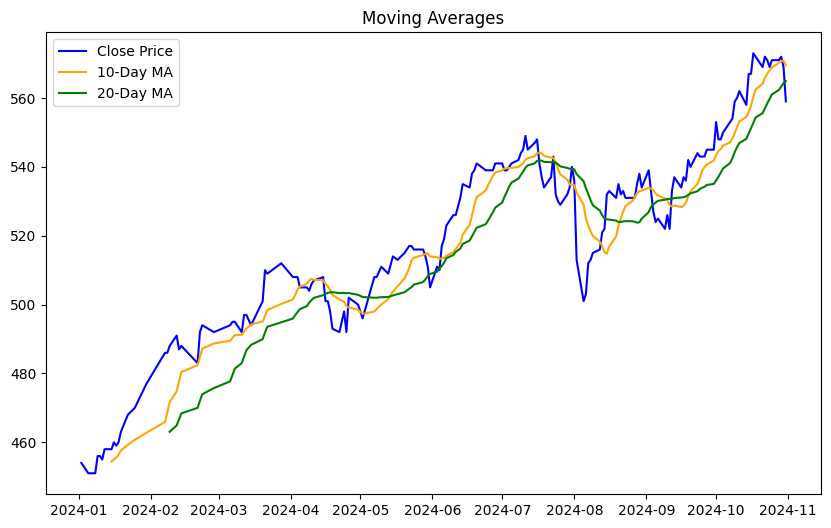

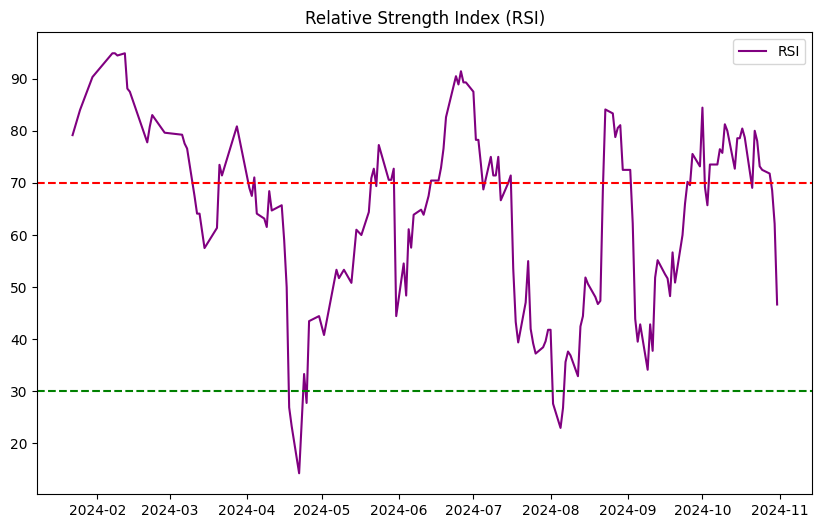

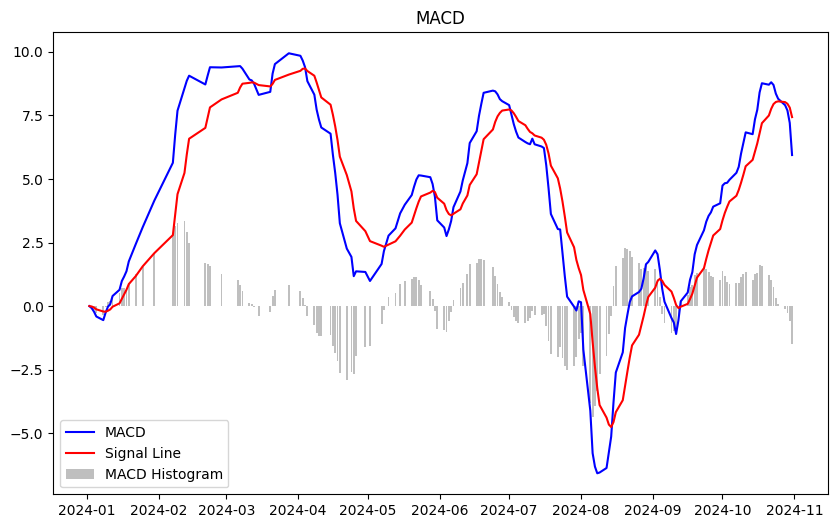

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Define Functions

def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window=period).mean()
    loss = (-delta.clip(upper=0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-9)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def compute_bollinger_bands(price, window=20, num_std=2):
    sma = price.rolling(window=window).mean()
    std = price.rolling(window=window).std()
    upper = sma + (num_std * std)
    lower = sma - (num_std * std)
    return sma, upper, lower

def compute_macd(series, short_window=12, long_window=26, signal_window=9):
    short_ema = series.ewm(span=short_window, adjust=False).mean()
    long_ema = series.ewm(span=long_window, adjust=False).mean()
    macd = short_ema - long_ema
    signal = macd.ewm(span=signal_window, adjust=False).mean()
    return macd, signal

# Load Your Data
# Example: Replace `data.csv` with your dataset file.
data = pd.read_csv("../data/historicalData_IE00B5BMR087_clean.csv")
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Filter for 2024 Dates
data = data.loc[data.index.year == 2024]

# Compute Indicators
close = data['Last Close']
data['RSI'] = compute_rsi(close)
data['10d_MA'] = close.rolling(window=10).mean()
data['20d_MA'] = close.rolling(window=20).mean()
data['BB_MID'], data['BB_UP'], data['BB_LOW'] = compute_bollinger_bands(close)
data['MACD'], data['MACD_SIGNAL'] = compute_macd(close)

# Plot Bollinger Bands
plt.figure(figsize=(10, 6))
plt.plot(close, label='Close Price', color='blue')
plt.plot(data['BB_MID'], label='Bollinger Middle Band', linestyle='--', color='orange')
plt.plot(data['BB_UP'], label='Bollinger Upper Band', linestyle='--', color='green')
plt.plot(data['BB_LOW'], label='Bollinger Lower Band', linestyle='--', color='red')
plt.fill_between(data.index, data['BB_LOW'], data['BB_UP'], color='orange', alpha=0.1)
plt.title('Bollinger Bands')
plt.legend()
plt.show()

# Plot Moving Averages
plt.figure(figsize=(10, 6))
plt.plot(close, label='Close Price', color='blue')
plt.plot(data['10d_MA'], label='10-Day MA', color='orange')
plt.plot(data['20d_MA'], label='20-Day MA', color='green')
plt.title('Moving Averages')
plt.legend()
plt.show()

# Plot RSI
plt.figure(figsize=(10, 6))
plt.plot(data['RSI'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title('Relative Strength Index (RSI)')
plt.legend()
plt.show()

# Plot MACD
plt.figure(figsize=(10, 6))
plt.plot(data['MACD'], label='MACD', color='blue')
plt.plot(data['MACD_SIGNAL'], label='Signal Line', color='red')
plt.bar(data.index, data['MACD'] - data['MACD_SIGNAL'], label='MACD Histogram', color='grey', alpha=0.5)
plt.title('MACD')
plt.legend()
plt.show()
